# Tutorial 1.1 - Deterministically Solving a Spatially Homogeneous Bimolecular System #

## Introduction ##
We start our tutorials on chemical kinetics by examining a simple reversible bimolecular reaction:

$$
A + B \xrightarrow{k_f} C
$$

$$
C \xrightarrow{k_r} A + B
$$

Using the law of mass action, we can write the dynamic behavior of the system as follows:

$$
\frac{d[A]}{dt} = \frac{d[B]}{dt} = -\frac{d[C]}{dt} = -k_{f}[A][B] + k_{r}[C]
$$

## Set the Working Directory and Import Packages ##
To solve this system, we will import functionalities from numpy, scipy and matplotlib as well as the general operating system package (os) to enable us to access various standard file commands. But first, we will use a predefined function to set our working directory.

In [4]:
# Import necessary packages #
import os, sys

# Define function to find desired working directory #
def _find_tutorial_dir(notebook_filename):
    """Locate this notebook's directory by searching upward from CWD."""
    start = os.path.abspath(os.getcwd())
    search = start
    for _ in range(8):
        if os.path.isfile(os.path.join(search, notebook_filename)):
            return search
        for subdir in ['LM/CME/Tutorial01_BimolecularReactions',
                       'CME/Tutorial01_BimolecularReactions',
                       'Tutorial01_BimolecularReactions']:
            candidate = os.path.abspath(os.path.join(search, subdir))
            if os.path.isfile(os.path.join(candidate, notebook_filename)):
                return candidate
        search = os.path.dirname(search)
    return None

# Define desired working directory #
_here = _find_tutorial_dir('Tut1.1-ODEBimol.ipynb')
if _here is None:
    raise RuntimeError(
        "Cannot locate Tutorial01_BimolecularReactions/. "
        "Please ensure the repository structure is intact."
    )

# Set working directory #
os.chdir(_here)
print(f"Working directory set to:\n{_here}")

Working directory set to:
/data/GitHub_Repos/SummerSchool_2026/LM/CME/Tutorial01_BimolecularReactions


Next, we will import other necessary packages and a custom script for plotting our results.

In [ ]:
# Import standard python libraries #
import numpy as np
import scipy.integrate as spi
import matplotlib.pyplot as plt

# Enable plotting inline in the Jupyter notebook #
%matplotlib inline

# Add Utils/ to path and import custom plotting module #
sys.path.insert(0, os.path.abspath('../Utils'))
import custom_plot as plot

## Define the Chemical System ##
Now that we have imported all necessary packages, we will begin to define our system. We start by setting the volume of our system, defining Avogadro's number, and choosing how long we want to simulate our system in biological time.

In [6]:
# Define system #
# Volume #
V  = 1.0e-15    # L
# Avogadro's number #
NA = 6.022e23   # Molecules/mole
# Simulation start time #
tstart =  0.0   # s
# Simulation end time #
tend   = 30.0   # s

Next, we will define which chemical species are present in the system and their abundances. Because we are using conventional deterministic methods, we want to define the amount of each species in concentrations which will correspond to the units used for the conventional rate constants.

In [ ]:
# Define all chemical species and their initial abundances #
# 50 molecules of species A #
A  = 50 / (NA*V) # Molar
# 50 molecules of species B #
B  = 50 / (NA*V) # Molar
# 0 molecules of species C #
C  = 0 / (NA*V)  # Molar
# Define a vector that holds initial state of the system #
S0 = [A, B, C]

Next, we will assign rate constants to all reactions in our system. We will also define a variable named `fold` which will allow us to change the magnitude of both rate constants in the future and observe how this affects the behavior of our system.

In [9]:
# Define fold variable for future analyses #
fold = 1
# Define rate constants for each reaction in the system #
# Forward reaction (A + B -> C) #
kf = fold * 1.07e6 # /Molar/s
# Reverse reaction (C -> A + B) #
kr = fold * 0.351  # /s

## Setup and Solve for Species Trajectories ##
Next, we will define a function that takes as its input the state of the system (abundances of each chemical species) and a vector representing evenly spaced timepoints from $t_{start}$ to $t_{end}$ at which to solve the system.

In [10]:
# Define function to accept system state and time vector and return instantaneous derivates for the abundance of each chemical species #
def ds_dt(s, t):
    # Define each chemical species from the input state vector #
    Ai = s[0]
    Bi = s[1]
    Ci = s[2]
    # Define rates of change for each species #
    dA_dt = -kf*Ai*Bi + kr*Ci
    dB_dt = -kf*Ai*Bi + kr*Ci
    dC_dt =  kf*Ai*Bi - kr*Ci
    # Return rates of change #
    return [dA_dt, dB_dt, dC_dt]

Now that our system has been fully defined, we will define our time vector using the numpy.linespace function. This vector will have 1,000,000 evenly spaced points between $t_{start}$ and $t_{end}$. After defining this vector, we will solve our system using the scipy.odeint function, thereby obtaining trajectories for each species.

In [11]:
# Define vector of timepoints at which to solve system #
t = np.linspace(tstart, tend, 1000000)
# Solve system for species trajectories #
soln = spi.odeint(ds_dt, S0, t)

## Analyze Species Trajectories ##
Now that we have solved for the system's species trajectories, we will plot the data to create a visual representation of the system over time. To do this, we will generate a new folder within our Tutorial01 directory named "Plots".

In [12]:
# Define directory name and path #
fig_dir = './Plots/'
# Create folder to store plotted figures #
if not os.path.exists(fig_dir):
    os.mkdir(fig_dir)

Using the custom function **`plot_time_ranges`**, we can visualize the species trajectories. If you are curious about plotting with Matplotlib, see the [Matplotlib Documentation](https://matplotlib.org/stable/api/pyplot_summary.html).

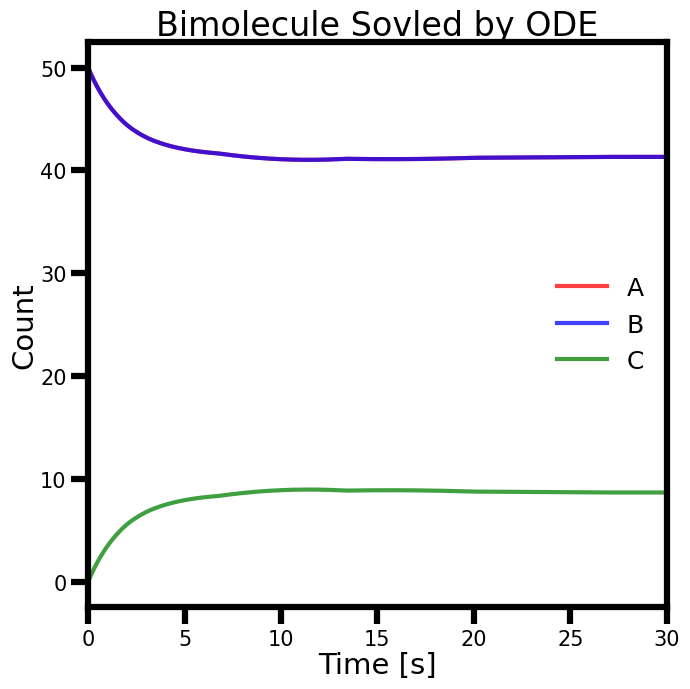

In [13]:
# Define plotting parameters #
fig_name = 'bimolecule_ODE_{0}foldrate'.format(fold)
fig_size = [7, 7] # Length by Height in inches
time = t
data_list=[NA*V*soln[:,0:1], NA*V*soln[:,1:2], NA*V*soln[:,2:3]]
legends = ['A','B','C']
colors = ['red', 'blue', 'green']
xlabel='Time [s]'
ylabel='Count'
title='Bimolecule Sovled by ODE'
percentile = [0,100]

# Plot the trajectories #
plot.plot_time_ranges(fig_dir, fig_name, fig_size,
               time, data_list, legends, colors, xlabel, ylabel, title,
               percentile, plot_avg=True, plot_range=False, xlimit=[tstart, tend],
               title_set=True, fonts_sizes=[21, 21, 24, 18],
               extension='.png', tick_setting=[12.0, 4.5, 15, 'out'],  line_widths = [3,4.5],
               legend_pos='best')

Generally, deterministic species trajectories have much higher molecule counts and are therefore represented in concentrations. However, we have opted to show the system trajectories in terms of actual molecule counts because we will want to compare this system solution with the solution of the stochastically solved system.